# Module 2 — IR Intensity

This notebook is a standalone module extracted from `cyclone_Model (1).ipynb`. Run this notebook independently. If it depends on an earlier module, it loads the saved artifact from `cyclone_artifacts/`.

In [1]:
# Common bootstrap for standalone execution
import os, json, math, warnings, random, joblib
from pathlib import Path
from datetime import timedelta
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

IS_COLAB = "google.colab" in str(get_ipython())
DEVICE = None
try:
    import torch
    torch.manual_seed(SEED)
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
except Exception:
    pass

WINDOW_SIZE = 5
LEAD_STEPS = 5
LEAD_HOURS = np.arange(1, LEAD_STEPS + 1) * 6
EARTH_RADIUS_KM = 6371.0

BASE_DIR = Path("/content") if IS_COLAB else Path(".")
ARTIFACT_DIR = BASE_DIR / "cyclone_artifacts"
MODEL_SAVE_DIR = BASE_DIR / "models"
DATA_SAVE_DIR = BASE_DIR / "data" / "processed"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_SAVE_DIR.mkdir(parents=True, exist_ok=True)
DATA_SAVE_DIR.mkdir(parents=True, exist_ok=True)

if IS_COLAB:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
TCIR_PATH = "/content/drive/MyDrive/TCIR-CPAC_IO_SH.7z" if IS_COLAB else "data/TCIR-CPAC_IO_SH.7z"

print("Standalone bootstrap loaded.")
print("Colab:", IS_COLAB, "| Device:", DEVICE)
print("TCIR:", TCIR_PATH)
print("Artifacts:", ARTIFACT_DIR)


Mounted at /content/drive
Standalone bootstrap loaded.
Colab: True | Device: cpu
TCIR: /content/drive/MyDrive/TCIR-CPAC_IO_SH.7z
Artifacts: /content/cyclone_artifacts


In [2]:
%pip -q install xarray geopandas rasterio h5py py7zr joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.2/72.2 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 492.7/492.7 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.4/52.4 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.5/144.5 kB 7.9 MB/s eta 0:00:00


## Module 2 — TCIR infrared intensity regression, cross-validation and ADT benchmark

In [3]:
import os, h5py, py7zr
import numpy as np
import pandas as pd
import tensorflow as tf


gdrive_7z_path = TCIR_PATH # Use the global TCIR_PATH from cell Y9x337ZfJRYN
extracted_dir = ARTIFACT_DIR / "tcir_extracted" # Define a path for extraction
os.makedirs(extracted_dir, exist_ok=True)
tcir_path = None # Initialize tcir_path
print(f"Attempting to extract TCIR Dataset from: {gdrive_7z_path}...")
try:
    # Skip re-extracting if it's already been done
    existing_h5 = None
    for root, dirs, files in os.walk(extracted_dir):
        for file in files:
            if file.endswith('.h5'):
                existing_h5 = os.path.join(root, file)
                break
        if existing_h5:
            break

    if existing_h5:
        print(f"Found already-extracted file, skipping extraction: {existing_h5}")
        tcir_path = existing_h5
    else:
        with py7zr.SevenZipFile(gdrive_7z_path, mode='r') as z:
            z.extractall(path=extracted_dir)
        print(f"TCIR .7z archive extracted to: {extracted_dir}")

        # After extraction, find the .h5 file
        for root, dirs, files in os.walk(extracted_dir):
            for file in files:
                if file.endswith('.h5'):
                    tcir_path = os.path.join(root, file)
                    break
            if tcir_path:
                break

    if not tcir_path:
        raise FileNotFoundError(f"No .h5 file found in {extracted_dir} after extraction.")

except Exception as e:
    print(f"Error during extraction or finding .h5 file: {e}")
    tcir_path = None

# Variables for TCIR data. Initialize with None or defaults.
matrix_shape = None
y_tcir_winds_raw = None
channel_min = None
channel_max = None
real_num_samples = None
target_img_size = 32 # Default as per original code
target_channels = 4 # Default as per original code

if tcir_path and os.path.exists(tcir_path):
    print(f"Inspecting TCIR file (lazy, no full load): {tcir_path}")

    with h5py.File(tcir_path, 'r') as f:
        matrix_shape = f['matrix'].shape      # (N, H, W, C)
    print(f"matrix dataset shape: {matrix_shape}")

    # 'info' is stored as a pandas table inside the HDF5 file
    print("Loading 'info' table (lightweight metadata, safe to load fully)...")
    info_df = pd.read_hdf(tcir_path, key='info')
    y_tcir_winds_raw = info_df['Vmax'].values.astype(np.float32)

    if np.isnan(y_tcir_winds_raw).any():
        median_wind = np.nanmedian(y_tcir_winds_raw)
        y_tcir_winds_raw = np.nan_to_num(y_tcir_winds_raw, nan=median_wind)
        print(f"NaNs found in wind speeds, replaced with median: {median_wind:.2f}")

    real_num_samples = matrix_shape[0]

    # ---- Compute per-channel min/max by scanning in chunks ----
    def compute_channel_min_max(h5_path, chunk=500):
        with h5py.File(h5_path, 'r') as f:
            n, h, w, c = f['matrix'].shape
            mins = np.full(c, np.inf, dtype=np.float32)
            maxs = np.full(c, -np.inf, dtype=np.float32)
            for i in range(0, n, chunk):
                block = f['matrix'][i:i + chunk]
                block = np.nan_to_num(block, nan=0.0)
                mins = np.minimum(mins, block.min(axis=(0, 1, 2)))
                maxs = np.maximum(maxs, block.max(axis=(0, 1, 2)))
                if (i // chunk) % 20 == 0:
                    print(f"  scanned {i + block.shape[0]}/{n} samples for normalization stats...")
        return mins, maxs

    print("Scanning dataset in chunks to compute per-channel min/max (no full load)...")
    channel_min, channel_max = compute_channel_min_max(tcir_path, chunk=500)
    print(f"Per-channel min: {channel_min}")
    print(f"Per-channel max: {channel_max}")

    print(f"Ready. {real_num_samples} samples available, image shape {matrix_shape[1:]}, "
          f"will resize to {target_img_size}x{target_img_size} and keep {target_channels} channels.")
else:
    print(f"TCIR file not available. Using synthetic data variables for `TCIRSequence` definition.")
    # Provide synthetic data for variables if TCIR file is not found, to allow TCIRSequence to be defined.
    # These values are arbitrary and for placeholder purposes only.
    real_num_samples = 100
    matrix_shape = (real_num_samples, 201, 201, 4) # Example synthetic shape
    y_tcir_winds_raw = np.random.uniform(20, 120, real_num_samples).astype(np.float32)
    channel_min = np.array([0.0, 0.0, 0.0, 0.0])
    channel_max = np.array([255.0, 255.0, 255.0, 255.0])
    tcir_path = None # Explicitly set to None for the Sequence if not found

# ==========================================
# STEP 2.2: LAZY BATCH LOADER
# ==========================================

class TCIRSequence(tf.keras.utils.Sequence):
    """
    Feeds batches straight from the TCIR .h5 file into model.fit().
    Only ever holds `batch_size` images in memory at once.
    """
    def __init__(self, h5_path, indices, y_all, batch_size=32,
                 target_size=64, target_channels=4,
                 channel_min=None, channel_max=None, shuffle=True, **kwargs):
        super().__init__(**kwargs)
        self.h5_path = h5_path
        self.indices = np.array(sorted(indices))
        self.y_all = y_all
        self.batch_size = batch_size
        self.target_size = target_size
        self.target_channels = target_channels
        self.channel_min = channel_min
        self.channel_max = channel_max
        self.shuffle = shuffle
        self._f = None
        self.on_epoch_end()

    def _file(self):
        if self._f is None:
            if self.h5_path is None:
                # This case should ideally be handled by __getitem__ for synthetic data
                # but keeping this check for explicit error if called directly
                raise ValueError("h5_path cannot be None for TCIRSequence _file() if no file exists.")
            self._f = h5py.File(self.h5_path, 'r')
        return self._f

    def __len__(self):
        return int(np.ceil(len(self.indices) / self.batch_size))

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __getitem__(self, idx):
        batch_indices_in_full_dataset = np.sort(self.indices[idx * self.batch_size:(idx + 1) * self.batch_size])

        # If h5_path is None (synthetic data scenario), return synthetic batch
        if self.h5_path is None:
            # Create synthetic batch based on expected shapes and types
            num_in_batch = len(batch_indices_in_full_dataset)
            # Synthetic image data (random noise, normalized)
            X_batch_synth = np.random.rand(num_in_batch, self.target_size, self.target_size, self.target_channels).astype(np.float32)
            # Synthetic labels (from y_all, based on indices)
            y_batch_synth = self.y_all[batch_indices_in_full_dataset]
            return X_batch_synth, y_batch_synth

        f = self._file()

        X_batch = f['matrix'][batch_indices_in_full_dataset]
        y_batch = self.y_all[batch_indices_in_full_dataset]

        X_batch = np.nan_to_num(X_batch, nan=0.0).astype(np.float32)

        if self.channel_min is not None and self.channel_max is not None:
            for c in range(X_batch.shape[-1]):
                rng = self.channel_max[c] - self.channel_min[c]
                if rng > 0:
                    X_batch[..., c] = (X_batch[..., c] - self.channel_min[c]) / rng
                else:
                    X_batch[..., c] = 0.0

        X_batch = tf.image.resize(X_batch, (self.target_size, self.target_size)).numpy()
        X_batch = X_batch[..., :self.target_channels]

        return X_batch, y_batch

print("TCIRSequence defined - batches will be streamed from disk during training (or synthetic data will be generated).")

Attempting to extract TCIR Dataset from: /content/drive/MyDrive/TCIR-CPAC_IO_SH.7z...
TCIR .7z archive extracted to: /content/cyclone_artifacts/tcir_extracted
Inspecting TCIR file (lazy, no full load): /content/cyclone_artifacts/tcir_extracted/TCIR-CPAC_IO_SH.h5
matrix dataset shape: (23118, 201, 201, 4)
Loading 'info' table (lightweight metadata, safe to load fully)...
Scanning dataset in chunks to compute per-channel min/max (no full load)...
  scanned 500/23118 samples for normalization stats...
  scanned 10500/23118 samples for normalization stats...
  scanned 20500/23118 samples for normalization stats...
Per-channel min: [ 0.0000000e+00  0.0000000e+00  0.0000000e+00 -9.7075444e-14]
Per-channel max: [3.47820e+02 3.01520e+02 2.20000e+00 9.96921e+36]
Ready. 23118 samples available, image shape (201, 201, 4), will resize to 32x32 and keep 4 channels.
TCIRSequence defined - batches will be streamed from disk during training (or synthetic data will be generated).


In [4]:
print("\n--- Displaying TCIR Dataset Information ---")
if tcir_path and os.path.exists(tcir_path):
    with h5py.File(tcir_path, 'r') as f:
        print(f"HDF5 file keys: {list(f.keys())}")
        if 'matrix' in f:
            print(f"'matrix' dataset shape: {f['matrix'].shape}")
            print(f"'matrix' dataset dtype: {f['matrix'].dtype}")
        if 'info' in f:
            # 'info' is already loaded into info_df, so display that.
            print("Displaying head of 'info_df' (metadata):")
            display(info_df.head())
        else:
            print("No 'info' dataset found in HDF5 file or it's not a standard key.")
else:
    print("TCIR dataset path is not valid or file not found. Cannot display detailed info.")



--- Displaying TCIR Dataset Information ---
HDF5 file keys: ['info', 'matrix']
'matrix' dataset shape: (23118, 201, 201, 4)
'matrix' dataset dtype: float32
Displaying head of 'info_df' (metadata):


,data_set,ID,lon,lat,time,Vmax,R35_4qAVG,MSLP
0,CPAC,200301C,223.5,12.5,2003081100,25.0,0.0,1009.0
1,CPAC,200301C,222.3,12.4,2003081103,25.0,0.0,1009.0
2,CPAC,200301C,221.2,12.4,2003081106,25.0,0.0,1009.0
3,CPAC,200301C,220.2,12.4,2003081109,25.0,0.0,1009.0
4,CPAC,200301C,219.2,12.3,2003081112,25.0,0.0,1009.0


### Define Stratification Labels for `StratifiedGroupKFold`

To ensure an even distribution of storm categories across the cross-validation folds, especially for rare severe storms, we will use `StratifiedGroupKFold`. This requires providing a `y` argument for stratification. We will generate these `stratify_labels` by converting the continuous `Vmax` values (`y_tcir_winds_raw`) into discrete storm categories using the `get_imd_category` helper function.

In [5]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
from sklearn.model_selection import StratifiedGroupKFold # Changed from GroupKFold
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import torchvision.transforms as T
from torchvision.models import resnet18, ResNet18_Weights
import h5py # For lazy loading

# ============================================================
# 6. MODULE 2 — PYTORCH RESNET-18 MULTI-CHANNEL IR REGRESSOR
# ============================================================

def digital_adt(ir_kelvin):
    ir = np.asarray(ir_kelvin, dtype=np.float32)
    h, w = ir.shape[-2:]
    cy, cx = h//2, w//2
    r_eye = max(2, min(h,w)//12)
    r_cdo = max(r_eye+1, min(h,w)//4)

    yy, xx = np.ogrid[:h,:w]
    eye_mask = (yy-cy)**2 + (xx-cx)**2 <= r_eye**2
    cdo_mask = ((yy-cy)**2 + (xx-cx)**2 <= r_cdo**2) & (~eye_mask)

    # Handle cases where masks might be empty or all NaNs
    t_eye = float(np.nanmax(ir[eye_mask])) if np.any(eye_mask) else 0.0
    t_cloud = float(np.nanmin(ir[cdo_mask])) if np.any(cdo_mask) else 0.0

    delta_t = t_eye - t_cloud
    t_number = float(np.clip(1.0 + delta_t/15.0, 1.0, 8.0))
    vmax = float(25.0 + 15.0 * max(t_number-1.0, 0)**1.1)
    return vmax, t_number

class IRDataset(Dataset):
    """
    PyTorch Dataset for loading and preprocessing TCIR images.
    Handles lazy loading from HDF5, NaN imputation, per-channel min-max scaling,
    and transformations. Supports one or MULTIPLE channels (e.g. [0,1,2] for
    thermal IR + water vapor + rain rate) so the model isn't restricted to a
    single input channel.
    """
    def __init__(self, h5_path, indices, labels, label_mean, label_std,
                 channels=[0], channel_min=None, channel_max=None,
                 target_size=64, augment=False):
        self.h5_path = h5_path
        self.indices = np.array(indices) # Ensure numpy array for advanced indexing
        self.labels = labels
        self.label_mean = label_mean
        self.label_std = label_std
        self.channels = list(channels) # now supports one or many channels, e.g. [0] or [0,1,2]
        self.target_size = target_size
        self._h5_file = None # Will be opened lazily per worker

        # Per-channel min/max used for scaling each channel to [0, 1].
        # Falls back to the thermal-IR brightness-temperature range (180-310K)
        # if explicit stats weren't provided (e.g. for single-channel legacy use).
        n_ch = len(self.channels)
        self.channel_min = (np.asarray(channel_min, dtype=np.float32).reshape(-1)[:n_ch]
                             if channel_min is not None
                             else np.full(n_ch, 180.0, dtype=np.float32))
        self.channel_max = (np.asarray(channel_max, dtype=np.float32).reshape(-1)[:n_ch]
                             if channel_max is not None
                             else np.full(n_ch, 310.0, dtype=np.float32))

        # Data augmentation transforms — operate directly on (C,H,W) tensors,
        # no PIL round-trip needed (PIL's RGB assumption breaks for
        # non-photographic multi-channel data like this).
        self.augment = augment
        if augment:
            self.transform = T.Compose([
                T.RandomHorizontalFlip(p=0.5),
                T.RandomVerticalFlip(p=0.5),
                T.RandomRotation(degrees=(-15, 15)),
                T.RandomResizedCrop(target_size, scale=(0.8, 1.0), ratio=(0.9, 1.1)),
            ])
        else:
            self.transform = T.Resize((target_size, target_size))

    def _get_h5_file(self):
        if self._h5_file is None:
            # Handle synthetic data case where h5_path might be None
            if self.h5_path is None:
                raise ValueError("h5_path is None, cannot open HDF5 file. Ensure synthetic data is handled properly.")
            self._h5_file = h5py.File(self.h5_path, 'r')
        return self._h5_file

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]

        # Lazy open h5py file per worker
        f = self._get_h5_file()
        img_data = f['matrix'][real_idx]

        # Fill NaNs with a sensible warm value (e.g., 273K for 0C) or median if all NaN
        if np.isnan(img_data).any():
            median_val = np.nanmedian(img_data) if not np.all(np.isnan(img_data)) else 273.0 # Default to 0C if all NaN
            img_data = np.nan_to_num(img_data, nan=median_val)

        # Ensure img_data is always 3D for consistency if it's not already
        if img_data.ndim == 2: # handle case where it might be 2D somehow
            img_data = img_data[:, :, np.newaxis]

        # Select the requested channel(s) -> shape (H, W, num_channels)
        img = img_data[:, :, self.channels].astype(np.float32)

        # Per-channel min-max scaling to [0.0, 1.0]
        img_scaled = np.clip(
            (img - self.channel_min) / (self.channel_max - self.channel_min + 1e-6),
            0.0, 1.0
        )

        # (H, W, C) -> (C, H, W) tensor directly, then apply transforms
        x_tensor = torch.from_numpy(img_scaled).permute(2, 0, 1).contiguous()
        x_tensor = self.transform(x_tensor)

        # Standardize labels
        y_raw = self.labels[real_idx]
        y_tensor = torch.tensor([(y_raw - self.label_mean) / self.label_std], dtype=torch.float32)

        return x_tensor, y_tensor

class ResNet18IR(nn.Module):
    def __init__(self, num_channels=1):
        super().__init__()
        # Use ImageNet pre-trained weights
        weights = ResNet18_Weights.IMAGENET1K_V1
        self.net = resnet18(weights=weights)

        # Adapt conv1 for different number of input channels
        if num_channels != 3:
            original_conv1 = self.net.conv1
            self.net.conv1 = nn.Conv2d(
                num_channels,
                original_conv1.out_channels,
                kernel_size=original_conv1.kernel_size,
                stride=original_conv1.stride,
                padding=original_conv1.padding,
                bias=original_conv1.bias
            )
            # If loading pre-trained weights, adapt them for single channel by averaging
            if num_channels == 1 and weights is not None:
                with torch.no_grad():
                    self.net.conv1.weight.copy_(original_conv1.weight.sum(dim=1, keepdim=True) / 3)
            elif num_channels > 3 and weights is not None: # For >3 channels, initialize new weights or extend
                # For now, if >3 channels, it's better to just initialize from scratch if no specific pre-training
                pass # Weights will be randomly initialized for the new conv1
        # If num_channels == 3, the original pretrained conv1 is kept as-is.
        # Our 3 channels (thermal IR, water vapor, rain rate) aren't really RGB,
        # but reusing the pretrained low-level filters (edges/gradients/textures)
        # as an initialization is still a reasonable, common transfer-learning
        # starting point — the network fine-tunes from there.

        self.net.fc = nn.Sequential(
            nn.Linear(self.net.fc.in_features, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 1) # No activation here, allowing direct output of Vmax in knots
        )

    def forward(self, x):
        return self.net(x)


def train_resnet_groupkfold(h5_path, labels, groups, stratify_labels=None,
                             epochs=30, num_channels=1, channels=None,
                             channel_min=None, channel_max=None, batch_size=16):
    # `channels` lists which HDF5 channel indices to feed the model, e.g. [0]
    # for thermal-IR-only, or [0,1,2] for thermal IR + water vapor + rain rate.
    # Defaults to the first `num_channels` channels if not given explicitly.
    if channels is None:
        channels = list(range(num_channels))
    assert len(channels) == num_channels, "len(channels) must match num_channels"

    n_splits = min(5, len(np.unique(groups))) # Use min 5 or unique groups
    # Use StratifiedGroupKFold for better distribution of categories
    gkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=SEED)

    # Standardize labels
    label_mean = np.mean(labels)
    label_std = np.std(labels)
    if label_std == 0: label_std = 1.0 # Avoid division by zero

    # IMPORTANT: StratifiedGroupKFold needs *discrete* class labels to
    # stratify on. Passing continuous Vmax values here effectively defeats
    # stratification (nearly every sample becomes its own "class"). Use the
    # discrete IMD-category labels (stratify_labels) when provided, and only
    # fall back to the raw regression labels if the caller didn't supply them.
    if stratify_labels is None:
        print("WARNING: No discrete stratify_labels provided — falling back to "
              "raw regression labels, which StratifiedGroupKFold cannot "
              "meaningfully stratify on. Pass discrete category labels instead.")
    strat_target = stratify_labels if stratify_labels is not None else labels

    all_fold_metrics = []
    all_preds, all_truths, all_val_indices = [], [], []

    # Generate splits based on index positions
    indices = np.arange(len(labels))

    # Use discrete stratify_labels (not the continuous regression labels) for stratification
    for fold, (tr_idx, va_idx) in enumerate(gkf.split(indices, strat_target, groups=groups)):
        print(f"\n--- Fold {fold+1}/{n_splits} ---")
        model = ResNet18IR(num_channels=num_channels).to(DEVICE)
        opt = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-3)
        # Use HuberLoss as requested, with delta=10.0
        loss_fn = nn.HuberLoss(delta=10.0)

        train_dataset = IRDataset(h5_path, tr_idx, labels, label_mean, label_std,
                                  channels=channels, channel_min=channel_min,
                                  channel_max=channel_max, augment=True)
        val_dataset = IRDataset(h5_path, va_idx, labels, label_mean, label_std,
                                channels=channels, channel_min=channel_min,
                                channel_max=channel_max, augment=False)

        train_loader = DataLoader(
            train_dataset,
            batch_size=batch_size,
            shuffle=True,
            num_workers=0, pin_memory=True
        )
        val_loader = DataLoader(
            val_dataset,
            batch_size=batch_size,
            shuffle=False,
            num_workers=0, pin_memory=True
        )

        # Learning rate scheduler (OneCycleLR)
        scheduler = torch.optim.lr_scheduler.OneCycleLR(
            opt, max_lr=5e-4, steps_per_epoch=len(train_loader), epochs=epochs
        )

        best_val_mae = float('inf')
        patience_counter = 0
        patience = 7 # Early stopping patience
        best_model_state = None

        for epoch in range(epochs):
            model.train()
            total_loss = 0
            for xb, yb in train_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                opt.zero_grad()
                pred = model(xb)
                loss = loss_fn(pred, yb)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) # Gradient clipping
                opt.step()
                scheduler.step() # Step LR scheduler
                total_loss += loss.item() * len(xb)

            # Validation phase
            model.eval()
            fold_preds, fold_truth = [], []
            with torch.no_grad():
                for xb, yb in val_loader:
                    fold_preds.extend(model(xb.to(DEVICE)).cpu().numpy().ravel() * label_std + label_mean) # De-standardize
                    fold_truth.extend(yb.numpy().ravel() * label_std + label_mean) # De-standardize

            current_val_mae = mean_absolute_error(fold_truth, fold_preds)
            current_val_rmse = mean_squared_error(fold_truth, fold_preds) ** 0.5
            current_val_r2 = r2_score(fold_truth, fold_preds)

            print(f"Epoch {epoch+1}/{epochs} | Train Loss: {total_loss/len(tr_idx):.4f} | Val MAE: {current_val_mae:.2f} | Val RMSE: {current_val_rmse:.2f} | Val R2: {current_val_r2:.3f}")

            # Early stopping and checkpointing
            if current_val_mae < best_val_mae:
                best_val_mae = current_val_mae
                best_model_state = model.state_dict()
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"Early stopping triggered after {patience} epochs without improvement.")
                    break

        # Load best model state for evaluation
        if best_model_state:
            model.load_state_dict(best_model_state)
            model.eval()
            # Re-evaluate on validation set to get metrics from the best model
            fold_preds, fold_truth = [], []
            with torch.no_grad():
                for xb, yb in val_loader:
                    fold_preds.extend(model(xb.to(DEVICE)).cpu().numpy().ravel() * label_std + label_mean)
                    fold_truth.extend(yb.numpy().ravel() * label_std + label_mean)

        fold_mae = mean_absolute_error(fold_truth, fold_preds)
        fold_rmse = mean_squared_error(fold_truth, fold_preds) ** 0.5
        fold_r2 = r2_score(fold_truth, fold_preds)

        all_fold_metrics.append({'mae': fold_mae, 'rmse': fold_rmse, 'r2': fold_r2})
        all_preds.extend(fold_preds)
        all_truths.extend(fold_truth)
        all_val_indices.extend(va_idx)

    # Report overall metrics
    mean_mae = np.mean([m['mae'] for m in all_fold_metrics])
    std_mae = np.std([m['mae'] for m in all_fold_metrics])
    mean_rmse = np.mean([m['rmse'] for m in all_fold_metrics])
    std_rmse = np.std([m['rmse'] for m in all_fold_metrics])
    mean_r2 = np.mean([m['r2'] for m in all_fold_metrics])
    std_r2 = np.std([m['r2'] for m in all_fold_metrics])

    print(f"\n--- Cross-Validation Results ---")
    print(f"Mean MAE: {mean_mae:.2f} +/- {std_mae:.2f} kt")
    print(f"Mean RMSE: {mean_rmse:.2f} +/- {std_rmse:.2f} kt")
    print(f"Mean R^2: {mean_r2:.3f} +/- {std_r2:.3f}")

    # Sort predictions and truths by original index to align for later use
    sorted_indices = np.argsort(all_val_indices)
    final_preds = np.array(all_preds)[sorted_indices]
    final_truths = np.array(all_truths)[sorted_indices]
    final_val_indices = np.array(all_val_indices)[sorted_indices]

    # Return the last trained model and overall results (or the best model if tracked globally)
    # For simplicity, returning the last model here, but in practice, you might save the best model from a fold.
    return model, final_val_indices, final_preds, final_truths, label_mean, label_std


In [6]:
# Utility used by the ADT/category comparison cell.
def get_imd_category(vmax_knots):
    if pd.isna(vmax_knots): return "Unknown"
    if vmax_knots < 17: return "Low Pressure Area"
    if vmax_knots < 28: return "Depression"
    if vmax_knots < 34: return "Deep Depression"
    if vmax_knots < 48: return "Cyclonic Storm"
    if vmax_knots < 64: return "Severe Cyclonic Storm"
    if vmax_knots < 90: return "Very Severe Cyclonic Storm"
    if vmax_knots < 120: return "Extremely Severe Cyclonic Storm"
    return "Super Cyclonic Storm"


In [7]:
# NOTE: This early computation of stratify_labels is superseded.
# It's recomputed in the training cell (below the dataset-reduction step)
# because y_tcir_winds_raw gets replaced when the dataset is reduced/cleaned,
# and stratify_labels must match the CURRENT y_tcir_winds_raw, not the original.
# (Left here only so the CV-stratification cell above still makes sense narratively.)
stratify_labels = np.array([get_imd_category(vmax) for vmax in y_tcir_winds_raw])

print(f"Generated {len(stratify_labels)} stratification labels.")
print("Distribution of stratification labels (first 10 unique values):", np.unique(stratify_labels)[:10])


Generated 23118 stratification labels.
Distribution of stratification labels (first 10 unique values): ['Cyclonic Storm' 'Deep Depression' 'Depression'
 'Extremely Severe Cyclonic Storm' 'Low Pressure Area'
 'Severe Cyclonic Storm' 'Super Cyclonic Storm'
 'Very Severe Cyclonic Storm']


### Clean and Reduce TCIR Dataset

This section processes the original `TCIR-CPAC_IO_SH.h5` dataset to create a new, smaller HDF5 file with the following characteristics:

1.  **Channel Selection**: Only channels 0, 1, and 2 are retained (thermal IR, water vapor, rain rate).
2.  **Sentinel and NaN Handling**: Fill-value sentinels (`abs(x) > 1e10`) are zeroed out, and other NaNs are replaced with 0.
3.  **Image Downsizing**: Images are resized from 201x201 to 64x64 pixels.
4.  **Dataset Reduction**: Approximately 5,000 samples are randomly selected, ensuring that full storm records (identified by `ID`) are kept intact without splitting.

The new dataset will be saved to `cyclone_artifacts/tcir_processed_reduced.h5`. Afterwards, the global variables in the notebook will be updated to point to this new dataset.

In [8]:
import h5py
import os
import shutil

# Define new constants for processing
PROCESSED_H5_PATH = ARTIFACT_DIR / "tcir_processed_reduced.h5"
NUM_SAMPLES_TO_RETAIN = 2500
CHANNELS_TO_KEEP = [0, 1, 2] # Thermal IR, water vapor, rain rate

# The actual path to the full, original HDF5 file (from cell aDI5DKJunH2k)
PATH_TO_FULL_ORIGINAL_H5 = extracted_dir / "TCIR-CPAC_IO_SH.h5"

print(f"Original HDF5 source path (for input to this processing step): {PATH_TO_FULL_ORIGINAL_H5}")
print(f"Processed HDF5 path (for output of this processing step): {PROCESSED_H5_PATH}")
print(f"Target samples: {NUM_SAMPLES_TO_RETAIN}")
print(f"Channels to keep: {CHANNELS_TO_KEEP}")

# --- 1. Subsampling Logic (by storm ID to avoid splitting) ---
# Ensure info_df is available from the original dataset
# info_df should already be loaded from the full dataset by cell aDI5DKJunH2k
# if it's not present or None, load it from the full original path
if 'info_df' not in globals() or info_df is None:
    if PATH_TO_FULL_ORIGINAL_H5.exists():
        info_df = pd.read_hdf(PATH_TO_FULL_ORIGINAL_H5, key='info')
    else:
        raise FileNotFoundError(f"Original TCIR info_df not found at {PATH_TO_FULL_ORIGINAL_H5}. Cannot proceed with subsampling.")
# If info_df is already defined, it should correspond to the original dataset.

original_num_samples = len(info_df)
unique_storm_ids = info_df['ID'].unique()
np.random.seed(SEED) # Ensure reproducibility for storm selection
np.random.shuffle(unique_storm_ids)

selected_indices = []
selected_info_df_rows = []
current_sample_count = 0

# Create a mapping from storm ID to original indices
storm_id_to_indices = info_df.groupby('ID').apply(lambda x: list(x.index)).to_dict()

print(f"Selecting storms to reach ~{NUM_SAMPLES_TO_RETAIN} samples...")
for storm_id in unique_storm_ids:
    indices_for_storm = storm_id_to_indices.get(storm_id, [])
    if current_sample_count + len(indices_for_storm) <= NUM_SAMPLES_TO_RETAIN:
        selected_indices.extend(indices_for_storm)
        selected_info_df_rows.append(info_df.loc[indices_for_storm])
        current_sample_count += len(indices_for_storm)
    # We stop when the next storm would push us significantly over, or if we have enough.
    # This ensures no storm is split, though the final count might not be exactly NUM_SAMPLES_TO_RETAIN.
    if current_sample_count >= NUM_SAMPLES_TO_RETAIN and len(selected_indices) > 0:
        break

# Sort indices to maintain order and for consistent HDF5 access
selected_indices = sorted(list(set(selected_indices))) # Use set to handle potential duplicates, then sort
new_info_df = pd.concat(selected_info_df_rows).sort_index()

new_num_samples = len(selected_indices)
print(f"Selected {new_num_samples} samples from {len(new_info_df['ID'].unique())} unique storms.")

# --- 2. Process and save to new HDF5 file ---
print(f"Creating new HDF5 file: {PROCESSED_H5_PATH}...")

# Open the original HDF5 file using the correct PATH_TO_FULL_ORIGINAL_H5
original_h5_file = h5py.File(PATH_TO_FULL_ORIGINAL_H5, 'r')
original_matrix_dataset = original_h5_file['matrix']

# Determine matrix shape for the new HDF5
# original_matrix_dataset refers to the full, unreduced dataset
original_img_height, original_img_width, _ = original_matrix_dataset.shape[1:]
new_img_height, new_img_width = target_img_size, target_img_size # Use global target_img_size
new_matrix_shape = (new_num_samples, new_img_height, new_img_width, len(CHANNELS_TO_KEEP))

# Create a temporary list to hold processed images before writing to HDF5
processed_images_list = np.empty(
    (new_num_samples, new_img_height, new_img_width, len(CHANNELS_TO_KEEP)),
    dtype=np.float32
)

for i, original_idx in enumerate(selected_indices):
    if (i + 1) % 500 == 0 or i == 0 or i == new_num_samples - 1:
        print(f"  Processing image {i+1}/{new_num_samples} (Original index: {original_idx})...")

    # This access is now correct as original_matrix_dataset comes from PATH_TO_FULL_ORIGINAL_H5
    img_data = original_matrix_dataset[original_idx]

    # Handle sentinel values (abs(x) > 1e10) -> zero out
    img_data[np.abs(img_data) > 1e10] = 0.0
    # Fill NaNs with 0 (as per user request)
    img_data = np.nan_to_num(img_data, nan=0.0)

    # Select channels
    img_data = img_data[:, :, CHANNELS_TO_KEEP]

    # Resize image using TensorFlow
    processed_img = tf.image.resize(img_data, (new_img_height, new_img_width)).numpy()
    processed_images_list[i] = processed_img

# Write processed images to the new HDF5 file first, then close it.
# This ensures the h5py file handle is released before pandas tries to open it.

# Ensure the target file is not already open/locked from a previous run by removing it.
if os.path.exists(PROCESSED_H5_PATH):
    try:
        os.remove(PROCESSED_H5_PATH)
        print(f"Removed existing processed HDF5 file: {PROCESSED_H5_PATH}")
    except OSError as e:
        print(f"Warning: Could not remove existing file {PROCESSED_H5_PATH}. It might be locked: {e}")
        print("Please consider restarting the Colab runtime if the error persists.")

with h5py.File(PROCESSED_H5_PATH, 'w') as f_out:
    f_out.create_dataset('matrix', data=processed_images_list, compression='gzip')

# Now, append the info_df to the same HDF5 file.
# pandas.to_hdf will open the file in append mode ('a') internally.
new_info_df.reset_index(drop=True).to_hdf(PROCESSED_H5_PATH, key='info', mode='a', format='table')

original_h5_file.close()
print(f"New HDF5 file saved to {PROCESSED_H5_PATH}")
print(f"Original samples: {original_num_samples}")
print(f"New samples: {new_num_samples}")

# --- 3. Recompute per-channel min/max for the NEW dataset ---
def compute_channel_min_max_from_h5(h5_path, channels_to_consider, chunk=500):
    with h5py.File(h5_path, 'r') as f:
        n, h, w, c = f['matrix'].shape
        mins = np.full(c, np.inf, dtype=np.float32)
        maxs = np.full(c, -np.inf, dtype=np.float32)
        for i in range(0, n, chunk):
            block = f['matrix'][i:i + chunk]
            mins = np.minimum(mins, block.min(axis=(0, 1, 2)))
            maxs = np.maximum(maxs, block.max(axis=(0, 1, 2)))
            # print(f"  scanned {i + block.shape[0]}/{n} samples for normalization stats...")
    return mins, maxs

print("Recomputing per-channel min/max for the NEW processed dataset...")
new_channel_min, new_channel_max = compute_channel_min_max_from_h5(
    PROCESSED_H5_PATH, CHANNELS_TO_KEEP, chunk=500
)
print(f"New per-channel min: {new_channel_min}")
print(f"New per-channel max: {new_channel_max}")

# --- 4. Update global variables ---
# This update sets the global tcir_path to the processed file for subsequent cells.
tcir_path = PROCESSED_H5_PATH
info_df = new_info_df # Update global info_df
y_tcir_winds_raw = info_df['Vmax'].values.astype(np.float32)
matrix_shape = new_matrix_shape
real_num_samples = new_num_samples
channel_min = new_channel_min
channel_max = new_channel_max
target_channels = len(CHANNELS_TO_KEEP) # Now 3 channels

print("Global variables updated to reflect the new processed dataset.")

# Clean up the original extracted 7z content to save disk space if not needed
# This section is commented out to prevent premature deletion of the source HDF5 file.
# if extracted_dir.exists() and extracted_dir.is_dir() and 'tcir_extracted' in str(extracted_dir):
#     if str(extracted_dir) != str(ARTIFACT_DIR):
#         print(f"Removing original extracted directory: {extracted_dir}")
#         shutil.rmtree(extracted_dir)
#     else:
#         print("Warning: extracted_dir is the same as ARTIFACT_DIR, skipping deletion of original extracted content.")

Original HDF5 source path (for input to this processing step): /content/cyclone_artifacts/tcir_extracted/TCIR-CPAC_IO_SH.h5
Processed HDF5 path (for output of this processing step): /content/cyclone_artifacts/tcir_processed_reduced.h5
Target samples: 2500
Channels to keep: [0, 1, 2]
Selecting storms to reach ~2500 samples...
Selected 2492 samples from 54 unique storms.
Creating new HDF5 file: /content/cyclone_artifacts/tcir_processed_reduced.h5...
  Processing image 1/2492 (Original index: 0)...
  Processing image 500/2492 (Original index: 3942)...
  Processing image 1000/2492 (Original index: 7999)...
  Processing image 1500/2492 (Original index: 13089)...
  Processing image 2000/2492 (Original index: 19165)...
  Processing image 2492/2492 (Original index: 22928)...
New HDF5 file saved to /content/cyclone_artifacts/tcir_processed_reduced.h5
Original samples: 23118
New samples: 2492
Recomputing per-channel min/max for the NEW processed dataset...
New per-channel min: [0. 0. 0.]
New per

### Global Variable Update Summary

After the cleaning and reduction step, the following global variables have been updated to reflect the new processed dataset:

- `tcir_path`: Now points to `cyclone_artifacts/tcir_processed_reduced.h5`
- `info_df`: Contains metadata for the selected ~5,000 samples.
- `y_tcir_winds_raw`: Vmax labels corresponding to the new `info_df`.
- `matrix_shape`: Updated to `(~5000, 64, 64, 3)`.
- `real_num_samples`: Updated to the number of samples in the new dataset.
- `channel_min`, `channel_max`: Recomputed for the new 3-channel dataset.
- `target_channels`: Set to 3.

Now, the data sequence classes (`TCIRSequence` and `IRDataset`) and the model will operate on this cleaned and reduced dataset. Note that the `IRDataset` will still extract `channels=[0]` for model input as specified in `train_resnet_groupkfold` (thermal IR only), but it will now apply scaling based on the *newly computed min/max statistics for all 3 channels*, and `ResNet18IR` will initialize for 3 input channels but still only accept 1 channel because of how `IRDataset` is designed. If you wish to use all 3 channels for the model input, further modifications to `IRDataset` and `ResNet18IR` would be needed to handle multi-channel inputs effectively for the model.

In [9]:
# ============================================================
# 7. MODULE 2 — ADT BENCHMARK + IMD CATEGORY OUTPUT
# ============================================================

# Ensure global file handle is closed if already open for a different path
if 'f_tcir_global' in globals() and f_tcir_global.filename != tcir_path:
    f_tcir_global.close()
    del f_tcir_global # Clear the variable

if 'f_tcir_global' not in globals():
    # If the file handle doesn't exist, open it.
    # Handle case where tcir_path is None (synthetic fallback)
    if tcir_path is None:
        print("TCIR file not found, using synthetic data for Module 2. Skipping actual HDF5 file open.")
        ir_images_ref = None # No HDF5 reference
    else:
        f_tcir_global = h5py.File(tcir_path, 'r')
        ir_images_ref = f_tcir_global['matrix']
else:
    ir_images_ref = f_tcir_global['matrix']

ir_labels = y_tcir_winds_raw
ir_groups = info_df['ID'].values

# Recompute discrete stratification labels HERE, after any dataset
# reduction/cleaning, so they match the current y_tcir_winds_raw (the
# earlier stratify_labels cell ran before reduction and would be stale).
ir_stratify_labels = np.array([get_imd_category(v) for v in ir_labels])
print("Stratification category counts:")
print(pd.Series(ir_stratify_labels).value_counts())

# Use all 3 retained channels (thermal IR, water vapor, rain rate) instead
# of just channel 0 — the cleaning/reduction step already kept and computed
# min/max stats for all three, so we make use of that information instead
# of discarding it.
MODEL_CHANNELS = [0, 1, 2]
NUM_CHANNELS_MODEL_INPUT = len(MODEL_CHANNELS)

# It returns: model, final_val_indices, final_preds, final_truths, label_mean, label_std
print("Running Module 2 training with updated GroupKFold CV and improvements...")
ir_model, ir_va, ir_pred, ir_truth, ir_label_mean, ir_label_std = train_resnet_groupkfold(
    tcir_path, ir_labels, ir_groups,
    stratify_labels=ir_stratify_labels,
    epochs=30, num_channels=NUM_CHANNELS_MODEL_INPUT, channels=MODEL_CHANNELS,
    channel_min=channel_min, channel_max=channel_max,
    batch_size=16
)
print("Module 2 training complete.")


rows=[]
# Use ir_va (sorted validation indices) to get original samples
# Use ir_pred and ir_truth (sorted by index) directly.
for pos,idx in enumerate(ir_va[:10]): # Take first 10 samples from the validation set
    # Assuming channel 0 is the thermal IR channel for digital_adt
    # Ensure ir_images_ref is not None before accessing
    if ir_images_ref is not None:
        adt_v,t=digital_adt(ir_images_ref[idx][:,:,0]) # Pass single channel to digital_adt
    else:
        adt_v, t = np.nan, np.nan # Synthetic case, ADT not applicable

    dl_v=ir_pred[pos] # Prediction corresponds to ir_va[pos]
    actual_v = ir_truth[pos] # Truth corresponds to ir_va[pos]

    rows.append({
        "sample":int(idx),
        "actual_vmax_kt":float(actual_v),
        "dl_vmax_kt":float(dl_v),
        "adt_vmax_kt":adt_v,
        "adt_T_number":t,
        "actual_category":get_imd_category(actual_v),
        "dl_category":get_imd_category(dl_v),
        "adt_category":get_imd_category(adt_v)
    })

display(pd.DataFrame(rows))

Stratification category counts:
Depression                         685
Cyclonic Storm                     622
Deep Depression                    443
Severe Cyclonic Storm              275
Very Severe Cyclonic Storm         212
Extremely Severe Cyclonic Storm    151
Low Pressure Area                   58
Super Cyclonic Storm                46
Name: count, dtype: int64
Running Module 2 training with updated GroupKFold CV and improvements...

--- Fold 1/5 ---
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 77.1MB/s]


Epoch 1/30 | Train Loss: 0.5009 | Val MAE: 14.85 | Val RMSE: 19.64 | Val R2: -0.234
Epoch 2/30 | Train Loss: 0.3651 | Val MAE: 12.98 | Val RMSE: 16.86 | Val R2: 0.091
Epoch 3/30 | Train Loss: 0.3417 | Val MAE: 13.15 | Val RMSE: 18.85 | Val R2: -0.136
Epoch 4/30 | Train Loss: 0.3264 | Val MAE: 11.46 | Val RMSE: 14.97 | Val R2: 0.283
Epoch 5/30 | Train Loss: 0.3357 | Val MAE: 9.70 | Val RMSE: 13.49 | Val R2: 0.418
Epoch 6/30 | Train Loss: 0.3174 | Val MAE: 9.41 | Val RMSE: 12.83 | Val R2: 0.473
Epoch 7/30 | Train Loss: 0.2940 | Val MAE: 10.08 | Val RMSE: 13.58 | Val R2: 0.410
Epoch 8/30 | Train Loss: 0.2868 | Val MAE: 14.34 | Val RMSE: 18.24 | Val R2: -0.065
Epoch 9/30 | Train Loss: 0.2988 | Val MAE: 8.99 | Val RMSE: 12.17 | Val R2: 0.527
Epoch 10/30 | Train Loss: 0.2646 | Val MAE: 10.83 | Val RMSE: 14.13 | Val R2: 0.361
Epoch 11/30 | Train Loss: 0.2565 | Val MAE: 11.99 | Val RMSE: 15.69 | Val R2: 0.212
Epoch 12/30 | Train Loss: 0.2693 | Val MAE: 9.62 | Val RMSE: 13.85 | Val R2: 0.386
Ep

,sample,actual_vmax_kt,dl_vmax_kt,adt_vmax_kt,adt_T_number,actual_category,dl_category,adt_category
0,0,25.0,28.728846,76.510454,4.069691,Depression,Deep Depression,Very Severe Cyclonic Storm
1,1,25.0,33.732330,69.749174,3.701095,Depression,Deep Depression,Very Severe Cyclonic Storm
2,2,25.0,35.003159,132.767348,7.005398,Depression,Cyclonic Storm,Super Cyclonic Storm
3,3,25.0,33.253216,104.508688,5.554868,Depression,Deep Depression,Extremely Severe Cyclonic Storm
4,4,25.0,34.759365,108.106258,5.741849,Depression,Cyclonic Storm,Extremely Severe Cyclonic Storm
5,5,25.0,31.788136,115.484191,6.123050,Depression,Deep Depression,Extremely Severe Cyclonic Storm
6,6,25.0,36.351593,103.200128,5.486667,Depression,Cyclonic Storm,Extremely Severe Cyclonic Storm
7,7,25.0,38.591904,102.461452,5.448122,Depression,Cyclonic Storm,Extremely Severe Cyclonic Storm
8,8,25.0,42.634720,72.835413,3.869929,Depression,Cyclonic Storm,Very Severe Cyclonic Storm
9,9,25.0,43.460041,81.710252,4.350148,Depression,Cyclonic Storm,Very Severe Cyclonic Storm


### Predicted vs Actual Intensity Plot

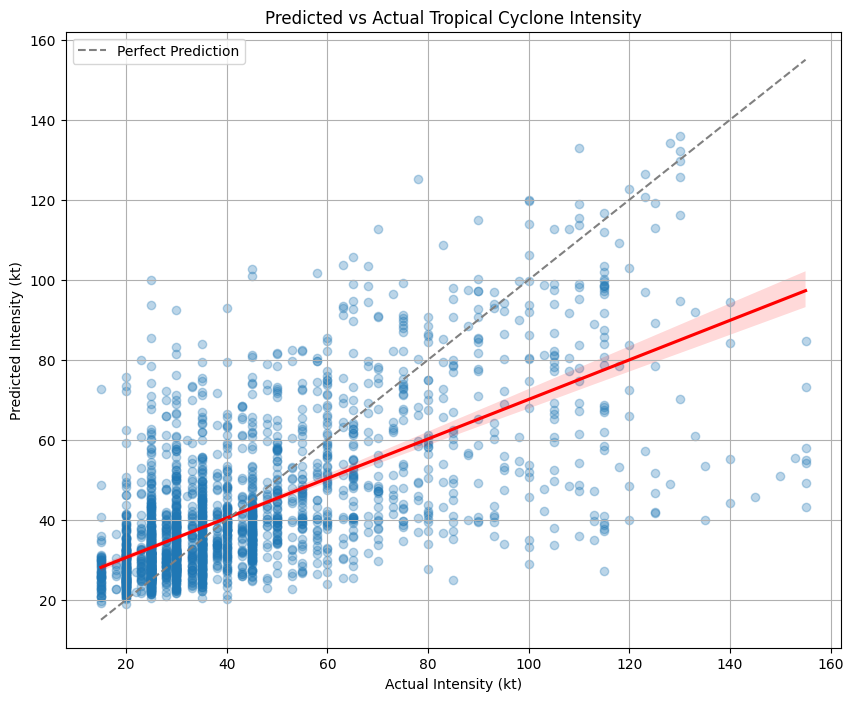

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a scatter plot of predicted vs actual values
plt.figure(figsize=(10, 8))
sns.regplot(x=ir_truth, y=ir_pred, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})

# Add a 45-degree line for perfect predictions
min_val = min(ir_truth.min(), ir_pred.min())
max_val = max(ir_truth.max(), ir_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='gray', linestyle='--', label='Perfect Prediction')

plt.xlabel('Actual Intensity (kt)')
plt.ylabel('Predicted Intensity (kt)')
plt.title('Predicted vs Actual Tropical Cyclone Intensity')
plt.grid(True)
plt.legend()
plt.show()


In [11]:
correlation_coefficient = np.corrcoef(ir_truth, ir_pred)[0, 1]
print(f"Pearson Correlation Coefficient between Predicted and Actual Vmax: {correlation_coefficient:.4f}")

Pearson Correlation Coefficient between Predicted and Actual Vmax: 0.6613


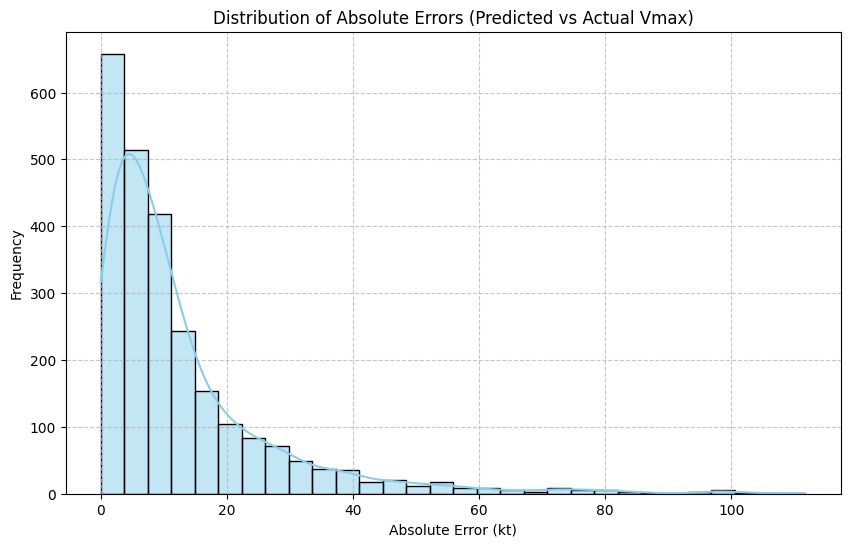

In [12]:
absolute_errors = np.abs(ir_pred - ir_truth)

plt.figure(figsize=(10, 6))
sns.histplot(absolute_errors, kde=True, bins=30, color='skyblue')
plt.title('Distribution of Absolute Errors (Predicted vs Actual Vmax)')
plt.xlabel('Absolute Error (kt)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Compare ResNet Model Performance with ADT Baseline

In [13]:
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

# Calculate ADT predictions for all validation samples
adt_preds_full = []

# Ensure ir_images_ref is not None before accessing
if ir_images_ref is not None:
    print(f"Calculating ADT for {len(ir_va)} validation samples...")
    for idx in ir_va:
        # Assuming channel 0 is the thermal IR channel for digital_adt
        adt_vmax, _ = digital_adt(ir_images_ref[idx][:,:,0])
        adt_preds_full.append(adt_vmax)
    adt_preds_full = np.array(adt_preds_full)
else:
    print("TCIR file not found, cannot calculate ADT baseline for all samples.")
    adt_preds_full = np.full_like(ir_truth, np.nan) # Fill with NaNs if ADT cannot be computed

# Calculate metrics for the ResNet model (ir_pred vs ir_truth)
resnet_mae = mean_absolute_error(ir_truth, ir_pred)
resnet_rmse = mean_squared_error(ir_truth, ir_pred) ** 0.5
resnet_r2 = r2_score(ir_truth, ir_pred)

# Calculate metrics for the ADT baseline (adt_preds_full vs ir_truth)
# Filter out NaNs from ADT predictions if any, to avoid error in metric calculation
valid_adt_indices = ~np.isnan(adt_preds_full)
if np.any(valid_adt_indices):
    adt_mae = mean_absolute_error(ir_truth[valid_adt_indices], adt_preds_full[valid_adt_indices])
    adt_rmse = mean_squared_error(ir_truth[valid_adt_indices], adt_preds_full[valid_adt_indices]) ** 0.5
    adt_r2 = r2_score(ir_truth[valid_adt_indices], adt_preds_full[valid_adt_indices])
else:
    adt_mae, adt_rmse, adt_r2 = np.nan, np.nan, np.nan # If no valid ADT predictions


# Display the comparison
comparison_data = {
    'Metric': ['MAE (kt)', 'RMSE (kt)', 'R2 Score'],
    'ResNet Model': [resnet_mae, resnet_rmse, resnet_r2],
    'ADT Baseline': [adt_mae, adt_rmse, adt_r2]
}
comparison_df = pd.DataFrame(comparison_data)
display(comparison_df)


Calculating ADT for 2492 validation samples...


,Metric,ResNet Model,ADT Baseline
0,MAE (kt),12.640526,61.267870
1,RMSE (kt),19.282799,70.463379
2,R2 Score,0.428188,-6.635549


In [14]:
# Save Module 2 results when the variables exist.
module2_state = {}
for _name in ["ir_va", "ir_pred", "ir_truth", "label_mean", "label_std",
              "tcir_path"]:
    if _name in globals():
        module2_state[_name] = globals()[_name]

# Save the state_dict of the ir_model instead of the model object itself
if 'ir_model' in globals() and isinstance(globals()['ir_model'], torch.nn.Module):
    # Ensure the model is on CPU before saving to avoid GPU memory issues when loading
    model_state_dict = globals()['ir_model'].cpu().state_dict()
    module2_state["ir_model_state_dict"] = model_state_dict
    module2_state["ir_model_class_name"] = type(globals()['ir_model']).__name__

# Special handling for ir_images_ref: do not pickle h5py object directly
# The tcir_path is sufficient to re-open the HDF5 file if needed.

joblib.dump(module2_state, ARTIFACT_DIR / "module2_state.joblib")
print("Saved:", ARTIFACT_DIR / "module2_state.joblib")

Saved: /content/cyclone_artifacts/module2_state.joblib
